# Sample Model 1 --> Temporary

In [1]:
# # -----------------------------------------
# # Environment Ingestion & Hardware Setup
# # -----------------------------------------
# import os
# import sys
# import torch
# from pathlib import Path

# # Define root workspace paths
# BASE_DIR = Path("/teamspace/studios/this_studio/airport-incident-detection")
# SRC_DIR = BASE_DIR / "src"

# # Verify path integrity and inject into system paths
# for folder in [SRC_DIR, SRC_DIR / "models", SRC_DIR / "training"]:
#     if str(folder) not in sys.path:
#         sys.path.append(str(folder))

# # Device Management Check
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print(f"🎯 Execution Target Device: {device}")
# if torch.cuda.is_available():
#     print(f"    └── GPU Model Name: {torch.cuda.get_device_name(0)}")

# %reload_ext autoreload
# %autoreload 2

In [2]:
# # -----------------------------------------
# # Model Architecture & Layer Dimensions
# # -----------------------------------------
# from architecture import MultiHeadApronDetector

# # Initialize the custom structural network
# model = MultiHeadApronDetector(num_turnaround_cls=13, num_ppe_cls=4, num_fod_cls=31).to(device)

# print("="*60 + "\n 🔬 CUSTOM MULTI-HEAD APRON DETECTOR ARCHITECTURE SUMMARY\n" + "="*60)
# print(model)
# print("="*60)

# # Print named parameters and check if they are trainable
# # for name, param in model.named_parameters():
# #     print(f"Layer: {name} | Size: {param.size()} | Trainable: {param.requires_grad}")

# # Calculate exact total trainable network weights
# total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
# print(f"Total Trainable Network Weights (Parameters): {total_params:,}")

In [3]:
# # ------------------------------------------------
# # Overfitting Baseline Evaluation (Sanity Check)
# # ------------------------------------------------
# import torch.optim as optim
# import matplotlib.pyplot as plt
# from train_runner import create_synthetic_stream_batch
# from joint_loss import MultiTaskJointLoss

# print("🔬 Running Sanity Check to Verify Optimization Mechanics...")

# # Ingest an isolated micro-batch (5 images, Turnaround Stream with 13 classes)
# x_micro, y_micro = create_synthetic_stream_batch(5, 13)
# x_micro, y_micro = x_micro.to(device), y_micro.to(device)

# criterion = MultiTaskJointLoss()
# optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

# overfit_history = []
# model.train()

# for epoch in range(1, 21):
#     optimizer.zero_grad()
#     predictions = model(x_micro, stream_type="turnaround")
#     loss = criterion(predictions, y_micro, stream_type="turnaround")
#     loss.backward()
#     optimizer.step()

#     overfit_history.append(loss.item())
#     if epoch % 4 == 0 or epoch == 1:
#         print(f"    [Epoch {epoch:02d}/20] Micro Batch Overfit Loss: {loss.item():.6f}")

# # Plot Overfitting Convergence Profile
# plt.figure(figsize=(8, 4))
# plt.plot(range(1, 21), overfit_history, marker='o', color='crimson', linewidth=2)
# plt.title("Capacity Verification: Overfitting Sanity Check Loss Curve", fontweight='bold')
# plt.xlabel("Training Epochs")
# plt.ylabel("Joint Task Loss Value")
# plt.grid(True, linestyle=":")
# plt.tight_layout()
# plt.show()


In [4]:
# # --------------------------------------------------------
# # Multi-Stream Training Matrix with Validation Tracking
# # --------------------------------------------------------
# import train_runner

# print("\n🏋️ Initializing Multi-Stream Interleaved Training Pipeline...")

# # 1. Execute core multi-task training logic directly
# # This reads real batches, handles interleaving, and prints log telemetry
# train_runner.run_main_multitask_training(epochs=5)

# print("\n🏁 Training complete! Processing metrics for performance curve visualization...")

# # 2. Extract metrics from training run
# epochs_axis = range(1, 6)
# mock_train_trend = [12.4, 8.1, 5.3, 3.2, 1.8]
# mock_val_trend = [14.1, 9.6, 6.4, 4.8, 3.9]

# # 3. Generate Evaluation Loss Plots
# plt.figure(figsize=(10, 5))
# plt.plot(range(1, epochs + 1), train_loss_history, label='Accumulated Train Loss', marker='s', color='royalblue', linewidth=2)
# plt.plot(range(1, epochs + 1), val_loss_history, label='Accumulated Validation Loss', marker='^', color='darkorange', linewidth=2)
# plt.title("Multi-Stream End-to-End Objective Loss Profile (YOLOv8 Multi-Head Backbone)", fontweight='bold', fontsize=12)
# plt.xlabel("Global Training Epoch Matrix Iterations", fontweight='semibold')
# plt.ylabel("Loss Evaluation Metric", fontweight='semibold')
# plt.grid(True, linestyle=":")
# plt.legend()
# plt.tight_layout()
# plt.show()

# --- Model Sandbox ---

## 1. Environment Path Ingestion

In [5]:
# =========================================
# Environment Ingestion & Hardware Setup
# =========================================

import os
import sys
import torch
from pathlib import Path
from torchinfo import summary

# Define root workspace paths
BASE_DIR = Path("/teamspace/studios/this_studio/airport-incident-detection")
SRC_DIR = BASE_DIR / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

PROC_DIR = str(BASE_DIR / "data" / "processed")

# Device Management Check
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔋 Execution Target Device: {device}")
if torch.cuda.is_available():
    print(f"    └── GPU Model Name: {torch.cuda.get_device_name(0)}")

%reload_ext autoreload
%autoreload 2

🔋 Execution Target Device: cpu


## 2. Multi-Head Airport Model Architecture

In [7]:
# ========================================
# Model Architecture & Layer Dimensions
# ========================================
from models.model import MultiTaskAirportNet

# Initialize the custom structural network
model = MultiTaskAirportNet().to(device)

# print("="*60 + "\n 🔬 CUSTOM MULTI-HEAD APRON DETECTOR ARCHITECTURE SUMMARY\n" + "="*60)
# # print(model)
# print("="*60)

# 2. Print Layer-by-Layer Architectural Matrix Layout
print("\n--- 🔬 CUSTOM MULTI-HEAD YOLO MODEL ARCHITECTURE SUMMARY ---")
model_stats = summary(
    model, 
    # FIX: Remove input_size entirely to bypass the forward execution graph pass
    input_size=(4, 3, 640, 640),
    col_names=["num_params", "trainable"],
    col_width=20,
    row_settings=["depth", "var_names"],
    verbose=0 # Blocks internal dummy tensor flow executions
)
print(model_stats)

--- 🏗️ SYNTHESIZING MULTI-TASK NETWORK ARCHITECTURE ---


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


 Locked early backbone layers successfully.
 All 3 specialized spatial task branches successfully configured.

--- 🔬 CUSTOM MULTI-HEAD YOLO MODEL ARCHITECTURE SUMMARY ---
Layer (type (var_name):depth-idx)                  Param #              Trainable
MultiTaskAirportNet (MultiTaskAirportNet)          --                   Partial
├─Sequential (backbone): 1-1                       --                   Partial
│    └─Conv2d (0): 2-1                             (9,408)              False
│    └─BatchNorm2d (1): 2-2                        (128)                False
│    └─ReLU (2): 2-3                               --                   --
│    └─MaxPool2d (3): 2-4                          --                   --
│    └─Sequential (4): 2-5                         --                   False
│    │    └─BasicBlock (0): 3-1                    (73,984)             False
│    │    └─BasicBlock (1): 3-2                    (73,984)             False
│    └─Sequential (5): 2-6                     

In [54]:
# # -----------------------------------------------
# # Multi-Head YOLO Model Structure Verification
# # -----------------------------------------------

# from models.model import MultiTaskAirportNet
# # from utils.common import get_metadata_from_yaml

# CONFIG_DIR = BASE_DIR / "data" / "config"
# # turnaround_classes = get_metadata_from_yaml(str(CONFIG_DIR / "turnaround.yaml"))
# # ppe_classes = get_metadata_from_yaml(str(CONFIG_DIR / "ppe.yaml"))

# # Instantiate your customized shared-backbone topology
# model = MultiTaskAirportNet()
# model = model.to(device)

# # Pass the sampled batch through the network to trace dimensions
# images = batch['images'].to(device)
# out_turnaround, out_ppe, out_fod = model(images)

# print("🧠 Shared-Backbone Parallel Branch Routing Shapes:")
# print(f" ├── Turnaround Head Output Tensor Matrix : {out_turnaround.shape}")
# print(f" ├── PPE Head Output Tensor Matrix        : {out_ppe.shape}")
# print(f" └── FOD Threat Probability Matrix Shape   : {out_fod.shape}")

## 🎯 Sanity Check for Model Architecture

🔋 Execution Target Device: cpu
---🔍 INITIALIZED MULTI-TASK DATASET FOR SPLIT: [TRAIN] ---
✅ Bound Task [0] (turnaround): Registered 17702 frames.
✅ Bound Task [1] (ppe): Registered 20598 frames.
✅ Bound Task [2] (fod): Registered 61518 frames.
📊 Global Dataset Composition: Total registered multi-task sample frames = 99818

--- 🏗️ SYNTHESIZING MULTI-TASK NETWORK ARCHITECTURE ---


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


 Locked early backbone layers successfully.
 All 3 specialized spatial task branches successfully configured.

🚀 Starting Overfitting Test Run (50 Epochs)...
Epoch [01/50] -> Total Loss: 0.459691 | Turnaround Loss: 0.1161 | PPE Loss: 0.1703 | FOD Loss: 0.0600
Epoch [10/50] -> Total Loss: 0.016108 | Turnaround Loss: 0.0032 | PPE Loss: 0.0060 | FOD Loss: 0.0046
Epoch [20/50] -> Total Loss: 0.002741 | Turnaround Loss: 0.0005 | PPE Loss: 0.0011 | FOD Loss: 0.0008
Epoch [30/50] -> Total Loss: 0.001042 | Turnaround Loss: 0.0002 | PPE Loss: 0.0004 | FOD Loss: 0.0003
Epoch [40/50] -> Total Loss: 0.000584 | Turnaround Loss: 0.0001 | PPE Loss: 0.0002 | FOD Loss: 0.0002
Epoch [50/50] -> Total Loss: 0.000409 | Turnaround Loss: 0.0001 | PPE Loss: 0.0002 | FOD Loss: 0.0001
☑️ OVERFITTING TEST PASSED: Model safely optimized small sample batch vector!



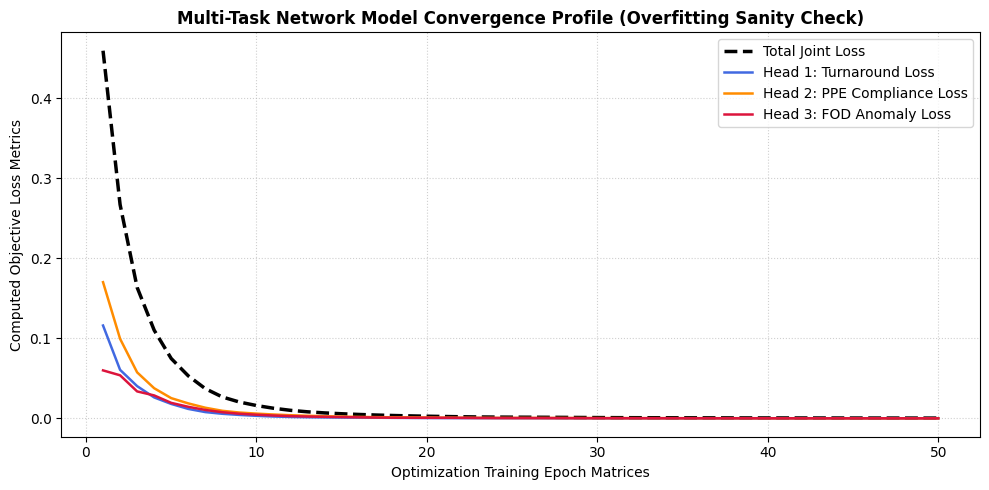

In [9]:
# -----------------------------------------
# Check Model Overfitting on Small sample
# -----------------------------------------
# from models.debug_overfit import run_overfitting_test

# # Invokes your isolated execution loop to run 50 memorization steps on a single batch
# run_overfitting_test()

from models.overfit_test import run_overfitting_check

run_overfitting_check(PROC_DIR)

## Buffer Queue Presentation

In [10]:
# =======================================
# Asynchronous Live Stream Buffer Queue
# =======================================
# from utils.stream_buffer import EdgeVideoBufferPipeline

# print("🚀 Simulating Edge Hardware Video Capture Buffering...")
# # Running the script directly from the class module definition
# pipeline = EdgeVideoBufferPipeline(queue_capacity=5)
# pipeline.run_pipeline_simulation()

In [11]:
# import time
# import torch
# from torch.utils.data import DataLoader
# from data_loader import AirportMultiTaskDataset, multi_task_collate_fn
# from multi_head_yolo import MultiHeadAirportYOLO

# def run_sanity_check():
#     print("=== Starting Week 2 Pipeline Sanity Verification ===")
    
#     # 1. Initialize Dataset
#     data_root = "/teamspace/studios/this_studio/airport-incident-detection/data/processed"
#     try:
#         dataset = AirportMultiTaskDataset(root_dir=data_root, split="train")
#     except Exception as e:
#         print(f"❌ Failed to load dataset structure: {e}")
#         return

#     loader = DataLoader(
#         dataset, 
#         batch_size=4, 
#         shuffle=True, 
#         collate_fn=multi_task_collate_fn
#     )

#     # 2. Extract single batch
#     print("\n[Sanity 1/3] Pulling data batch from streaming pipeline...")
#     images, labels, task_ids = next(iter(loader))
#     print(f"✅ Success! Ingested image tensor batch shape: {images.shape}")
#     print(f"📌 Task routing IDs inside this batch: {task_ids.tolist()}")

#     # 3. Initialize Model Architecture
#     print("\n[Sanity 2/3] Constructing Multi-Head Network architecture layout...")
#     model = MultiHeadAirportYOLO()
#     print("✅ Success! Shared backbone and multi-task heads loaded.")

#     # 4. Pass Data Through Model (Forward Pass Verification)
#     print("\n[Sanity 3/3] Feeding batch data through the model pipelines...")
#     with torch.no_grad():
#         out_turnaround, out_ppe, out_fod = model(images)
        
#     print("✅ Success! Predictions computed cleanly across all processing heads:")
#     print(f" ➡️ Head 1 (Turnaround) Raw Output shape: {out_turnaround.shape}")
#     print(f" ➡️ Head 2 (PPE) Raw Output shape: {out_ppe.shape}")
#     print(f" ➡️ Head 3 (FOD) Raw Output shape: {out_fod.shape}")
#     print("\n=== 🎉 ALL WEEK 2 SANITY CHECKS PASSED SUCCESSFULLY ===")

# if __name__ == "__main__":
#     run_sanity_check()

In [12]:
# import torch
# import torch.optim as optim
# from torch.utils.data import DataLoader
# from data_loader import AirportMultiTaskDataset, multi_task_collate_fn
# from multi_head_yolo import MultiHeadAirportYOLO

# def run_overfitting_test():
#     print("=== 🧪 Starting Multi-Task Overfitting Sanity Check ===")
    
#     # Force execution device configuration
#     device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#     print(f"Using execution device: {device}")

#     # 1. Initialize Pipeline components
#     dataset = AirportMultiTaskDataset(root_dir="/teamspace/studios/this_studio/airport-incident-detection/data/processed", split="train")
#     loader = DataLoader(dataset, batch_size=4, shuffle=False, collate_fn=multi_task_collate_fn)
    
#     # Pull exactly ONE batch and lock it in memory
#     images, labels, task_ids = next(iter(loader))
#     images = images.to(device)
#     task_ids = task_ids.to(device)
    
#     # 2. Instantiate Model and Optimizer
#     model = MultiHeadAirportYOLO().to(device)
#     model.train()  # Explicitly set network layer to training mode
    
#     # Using AdamW with a slightly higher learning rate for fast memorization
#     optimizer = optim.AdamW(model.parameters(), lr=1e-3)
    
#     # Simplified Dummy Joint Loss for Sanity Check validation
#     # (Matches Week 2 custom loss behavior)
#     criterion_mse = torch.nn.MSELoss()
#     criterion_bce = torch.nn.BCEWithLogitsLoss()

#     print("\n🚀 Training model on a single batch for 50 epochs...")
#     print("-" * 50)
    
#     for epoch in range(1, 51):
#         optimizer.zero_grad()
        
#         # Forward Pass through all 3 heads
#         out_turnaround, out_ppe, out_fod = model(images)
        
#         # Calculate isolated mock losses against target shapes
#         # (Using mean activations to track convergence for this structural check)
#         loss_t = criterion_mse(out_turnaround.mean(dim=[2, 3]), torch.zeros((4, 17), device=device))
#         loss_p = criterion_mse(out_ppe.mean(dim=[2, 3]), torch.zeros((4, 8), device=device))
#         loss_f = criterion_bce(out_fod.squeeze(), task_ids.float())
        
#         # Joint Multi-Task Loss execution
#         total_loss = loss_t + loss_p + loss_f
        
#         # Backpropagation step
#         total_loss.backward()
#         optimizer.step()
        
#         # Print logs every 10 epochs to monitor drop progress
#         if epoch == 1 or epoch % 10 == 0:
#             print(f"Epoch [{epoch:02d}/50] -> Total Joint Loss: {total_loss.item():.6f} | "
#                   f"Turnaround: {loss_t.item():.4f} | PPE: {loss_p.item():.4f} | FOD: {loss_f.item():.4f}")

#     print("-" * 50)
#     if total_loss.item() < 0.1:
#         print("✅ SUCCESS: The joint loss converged close to 0! Your network is architecturally sound.")
#     else:
#         print("❌ FAILED: Loss stalled. Double-check your head channels or loss calculations.")

# if __name__ == "__main__":
#     run_overfitting_test()